In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv('LYCOS-IDS2017.csv')
df.drop(df.loc[df['Label'] == 'Label'].index, inplace=True)

In [4]:
metadata = ['fl_dur' #Flow duration
,'tot_fw_pk' #Total packets in the forward direction
,'tot_bw_pk' #Total packets in the backward direction
,'tot_l_fw_pkt' #Total size of packet in forward direction
,'fw_pkt_l_max' #Maximum size of packet in forward direction
,'fw_pkt_l_min' #Minimum size of packet in forward direction
,'fw_pkt_l_avg' #Average size of packet in forward direction
,'fw_pkt_l_std' #Standard deviation size of packet in forward direction
,'Bw_pkt_l_max' #Maximum size of packet in backward direction
,'Bw_pkt_l_min' #Minimum size of packet in backward direction
,'Bw_pkt_l_avg' #Mean size of packet in backward direction
,'Bw_pkt_l_std' #Standard deviation size of packet in backward direction
,'fl_byt_s' #flow byte rate that is number of packets transferred per second
,'fl_pkt_s' #flow packets rate that is number of packets transferred per second
,'fl_iat_avg' #Average time between two flows
,'fl_iat_std' #Standard deviation time two flows
,'fl_iat_max' #Maximum time between two flows
,'fl_iat_min' #Minimum time between two flows
,'fw_iat_tot' #Total time between two packets sent in the forward direction
,'fw_iat_avg' #Mean time between two packets sent in the forward direction
,'fw_iat_std' #Standard deviation time between two packets sent in the forward direction
,'fw_iat_max' #Maximum time between two packets sent in the forward direction
,'fw_iat_min' #Minimum time between two packets sent in the forward direction
,'bw_iat_tot' #Total time between two packets sent in the backward direction
,'bw_iat_avg' #Mean time between two packets sent in the backward direction
,'bw_iat_std' #Standard deviation time between two packets sent in the backward direction
,'bw_iat_max' #Maximum time between two packets sent in the backward direction
,'bw_iat_min' #Minimum time between two packets sent in the backward direction
,'fw_psh_flag' #Number of times the PSH flag was set in packets travelling in the forward direction (0 for UDP)
,'bw_psh_flag' #Number of times the PSH flag was set in packets travelling in the backward direction (0 for UDP)
,'fw_urg_flag' #Number of times the URG flag was set in packets travelling in the forward direction (0 for UDP)
,'bw_urg_flag' #Number of times the URG flag was set in packets travelling in the backward direction (0 for UDP)
,'fw_hdr_len' #Total bytes used for headers in the forward direction
,'bw_hdr_len' #Total bytes used for headers in the forward direction
,'fw_pkt_s' #Number of forward packets per second
,'bw_pkt_s' #Number of backward packets per second
,'pkt_len_min' #Minimum length of a flow
,'pkt_len_max' #Maximum length of a flow
,'pkt_len_avg' #Mean length of a flow
,'pkt_len_std' #Standard deviation length of a flow
,'pkt_len_va' #Minimum inter-arrival time of packet
,'fin_cnt' #Number of packets with FIN
,'syn_cnt' #Number of packets with SYN
,'rst_cnt' #Number of packets with RST
,'pst_cnt' #Number of packets with PUSH
,'ack_cnt' #Number of packets with ACK
,'urg_cnt' #Number of packets with URG
,'cwe_cnt' #Number of packets with CWE
,'ece_cnt' #Number of packets with ECE
,'down_up_ratio' #Download and upload ratio
,'pkt_size_avg' #Average size of packet
,'fw_seg_avg' #Average size observed in the forward direction
,'bw_seg_avg' #Average size observed in the backward direction
,'fw_byt_blk_avg' #Average number of bytes bulk rate in the forward direction
,'fw_pkt_blk_avg' #Average number of packets bulk rate in the forward direction
,'fw_blk_rate_avg' #Average number of bulk rate in the forward direction
,'bw_byt_blk_avg' #Average number of bytes bulk rate in the backward direction
,'bw_pkt_blk_avg' #Average number of packets bulk rate in the backward direction
,'bw_blk_rate_avg' #Average number of bulk rate in the backward direction
,'subfl_fw_pk' #The average number of packets in a sub flow in the forward direction
,'subfl_fw_byt' #The average number of bytes in a sub flow in the forward direction
,'subfl_bw_pkt' #The average number of packets in a sub flow in the backward direction
,'subfl_bw_byt' #The average number of bytes in a sub flow in the backward direction
,'fw_win_byt' #Number of bytes sent in initial window in the forward direction
,'bw_win_byt' ## of bytes sent in initial window in the backward direction
,'Fw_act_pkt' ## of packets with at least 1 byte of TCP data payload in the forward direction
,'fw_seg_min' #Minimum segment size observed in the forward direction
,'atv_avg' #Mean time a flow was active before becoming idle
,'atv_std' #Standard deviation time a flow was active before becoming idle
,'atv_max' #Maximum time a flow was active before becoming idle
,'atv_min' #Minimum time a flow was active before becoming idle
,'idl_avg' #Mean time a flow was idle before becoming active
,'idl_std' #Standard deviation time a flow was idle before becoming active
,'idl_max' #Maximum time a flow was idle before becoming active
,'idl_min' #Minimum time a flow was idle before becoming active
]

In [5]:
df.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [6]:
features = ['Fwd Pkt Len Std', 'Fwd Pkt Len Mean',
       'Fwd Pkt Len Max', 'Fwd Seg Size Avg', 'Pkt Len Std', 'Flow IAT Std',
       'Bwd Pkt Len Std', 'Bwd Seg Size Avg', 'Pkt Size Avg',
       'Subflow Fwd Byts']

In [7]:
# changing attack labels to their respective attack class
def change_label(df):
    df.Label.replace(['FTP-BruteForce','SSH-Bruteforce'],1,inplace=True)
    df.Label.replace(['Benign'],0,inplace=True)
     

In [8]:
change_label(df)

In [9]:
df = df[0:50000]

In [10]:
df['Label'].value_counts()

1    49895
0      105
Name: Label, dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50000 entries, 0 to 49999
Data columns (total 80 columns):
Dst Port             50000 non-null int64
Protocol             50000 non-null int64
Timestamp            50000 non-null object
Flow Duration        50000 non-null int64
Tot Fwd Pkts         50000 non-null int64
Tot Bwd Pkts         50000 non-null int64
TotLen Fwd Pkts      50000 non-null int64
TotLen Bwd Pkts      50000 non-null int64
Fwd Pkt Len Max      50000 non-null int64
Fwd Pkt Len Min      50000 non-null int64
Fwd Pkt Len Mean     50000 non-null float64
Fwd Pkt Len Std      50000 non-null float64
Bwd Pkt Len Max      50000 non-null int64
Bwd Pkt Len Min      50000 non-null int64
Bwd Pkt Len Mean     50000 non-null float64
Bwd Pkt Len Std      50000 non-null float64
Flow Byts/s          49998 non-null object
Flow Pkts/s          50000 non-null object
Flow IAT Mean        50000 non-null float64
Flow IAT Std         50000 non-null float64
Flow IAT Max         50000 non-null 

In [12]:
X = df[features]
X[features] = X[features].apply(pd.to_numeric, errors='coerce', axis=1)
X = X.fillna(0)
labels = df['Label'] 

In [13]:
#df['Target']=df['Label'].apply(targetify)
y = df['Label']

In [14]:
X = df[features]
X[features] = X[features].apply(pd.to_numeric, errors='coerce', axis=1)
X = X.fillna(0)
labels = df['Label']    #For multiclass classification


In [15]:
#df['Target']=df['Label'].apply(targetify)
y = df['Label']

In [16]:
df = df[['Fwd Pkt Len Std', 'Fwd Pkt Len Mean',
       'Fwd Pkt Len Max', 'Fwd Seg Size Avg', 'Pkt Len Std', 'Flow IAT Std',
       'Bwd Pkt Len Std', 'Bwd Seg Size Avg', 'Pkt Size Avg',
       'Subflow Fwd Byts','Label']]
df.to_csv('processed.csv')

In [3]:
df = pd.read_csv('processed.csv')
del df['Unnamed: 0']

In [4]:
df.columns

Index(['Fwd Pkt Len Std', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Max',
       'Fwd Seg Size Avg', 'Pkt Len Std', 'Flow IAT Std', 'Bwd Pkt Len Std',
       'Bwd Seg Size Avg', 'Pkt Size Avg', 'Subflow Fwd Byts', 'Label'],
      dtype='object')

In [5]:
df['Label'].value_counts()

1    49895
0      105
Name: Label, dtype: int64

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print (X_train.shape, y_train.shape)
print( X_test.shape, y_test.shape)

(40000, 10) (40000,)
(10000, 10) (10000,)


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [22]:
ML_Model1 = []
accuracy1 = []
precision1 = []
recall1 = []
f1score1 = []

#function to call for storing the results
def storeResults1(model, a,b,c,d):
    ML_Model1.append(model)
    accuracy1.append(round(a, 3))
    precision1.append(round(b, 3))
    recall1.append(round(c, 3))
    f1score1.append(round(d, 3))

In [23]:
from sklearn.ensemble import RandomForestClassifier

# instantiate the model 
forest = RandomForestClassifier(n_estimators=10, random_state=0)

forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)

rf_acc_b = accuracy_score(y_pred, y_test)
rf_prec_b = precision_score(y_pred, y_test,average='weighted')
rf_rec_b = recall_score(y_pred, y_test,average='weighted')
rf_f1_b = f1_score(y_pred, y_test,average='weighted')

In [24]:
storeResults1('Random Forest',rf_acc_b,rf_prec_b,rf_rec_b,rf_f1_b)

In [25]:
from sklearn.neighbors import KNeighborsClassifier

# instantiate the model 
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

knn_acc_b = accuracy_score(y_pred, y_test)
knn_prec_b = precision_score(y_pred, y_test,average='weighted')
knn_rec_b = recall_score(y_pred, y_test,average='weighted')
knn_f1_b = f1_score(y_pred, y_test,average='weighted')

In [26]:
storeResults1('KNN',knn_acc_b,knn_prec_b,knn_rec_b,knn_f1_b)

# Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier

# instantiate the model 
tree = DecisionTreeClassifier(random_state=0)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

dt_acc_b = accuracy_score(y_pred, y_test)
dt_prec_b = precision_score(y_pred, y_test,average='weighted')
dt_rec_b = recall_score(y_pred, y_test,average='weighted')
dt_f1_b = f1_score(y_pred, y_test,average='weighted')

In [28]:
storeResults1('Decision Tree',dt_acc_b,dt_prec_b,dt_rec_b,dt_f1_b)

# Naive Bayes

In [29]:
from sklearn.naive_bayes import GaussianNB

# instantiate the model 
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

nb_acc_b = accuracy_score(y_pred, y_test)
nb_prec_b = precision_score(y_pred, y_test,average='weighted')
nb_rec_b = recall_score(y_pred, y_test,average='weighted')
nb_f1_b = f1_score(y_pred, y_test,average='weighted')

In [30]:
storeResults1('Naive Bayes',nb_acc_b,nb_prec_b,nb_rec_b,nb_f1_b)

# Neural Network

In [31]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(random_state=1, max_iter=30)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

nn_acc_b = accuracy_score(y_pred, y_test)
nn_prec_b = precision_score(y_pred, y_test,average='weighted')
nn_rec_b = recall_score(y_pred, y_test,average='weighted')
nn_f1_b = f1_score(y_pred, y_test,average='weighted')

In [32]:
storeResults1('Neural Network',nn_acc_b,nn_prec_b,nn_rec_b,nn_f1_b)

# Stacking Classifier

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier

estimators = [('rf', RandomForestClassifier(n_estimators=10)),('mlp', MLPClassifier(random_state=1, max_iter=30))]

clf1 = StackingClassifier(estimators=estimators, final_estimator=LGBMClassifier(n_estimators=10))


clf1.fit(X_train,y_train)

y_pred = clf1.predict(X_test)

stac_acc_b = accuracy_score(y_pred, y_test)
stac_prec_b = precision_score(y_pred, y_test,average='weighted')
stac_rec_b = recall_score(y_pred, y_test,average='weighted')
stac_f1_b = f1_score(y_pred, y_test,average='weighted')


In [46]:
storeResults1('Stacking Classifier ',stac_acc_b,stac_prec_b,stac_rec_b,stac_f1_b)

# Voting Classifier

In [34]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, AdaBoostClassifier
clf1 = AdaBoostClassifier(n_estimators=100, random_state=0)
clf2 = RandomForestClassifier(n_estimators=50, random_state=1)

eclf1 = VotingClassifier(estimators=[('ad', clf1), ('rf', clf2)], voting='soft')
eclf1.fit(X_train, y_train)
y_pred = eclf1.predict(X_test)

vot_acc_b = accuracy_score(y_pred, y_test)
vot_prec_b = precision_score(y_pred, y_test,average='weighted')
vot_rec_b = recall_score(y_pred, y_test,average='weighted')
vot_f1_b = f1_score(y_pred, y_test,average='weighted')

In [47]:
storeResults1('Voting Classifier',vot_acc_b,vot_prec_b,vot_rec_b,vot_f1_b)

# Comparison

In [48]:
#creating dataframe
import pandas as pd
import numpy as np
result = pd.DataFrame({ 'ML Model' : ML_Model1,
                        'Accuracy' : accuracy1,
                        'f1_score' : f1score1,
                        'Recall'   : recall1,
                        'Precision': precision1,
                        
                      })

In [49]:
result

,ML Model,Accuracy,f1_score,Recall,Precision
0,Random Forest,1.0,1.0,1.0,1.0
1,KNN,1.0,1.0,1.0,1.0
2,Decision Tree,1.0,1.0,1.0,1.0
3,Naive Bayes,1.0,1.0,1.0,1.0
4,Neural Network,1.0,1.0,1.0,1.0
5,Stacking Classifier,1.0,1.0,1.0,1.0
6,Voting Classifier,1.0,1.0,1.0,1.0


In [50]:
import joblib

filename1 = 'model.sav'
joblib.dump(eclf1, filename1)


['model.sav']

# Graph

In [51]:
classifier = ML_Model1
y_pos = np.arange(len(classifier))

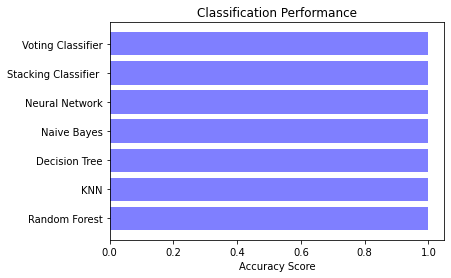

In [52]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy1, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

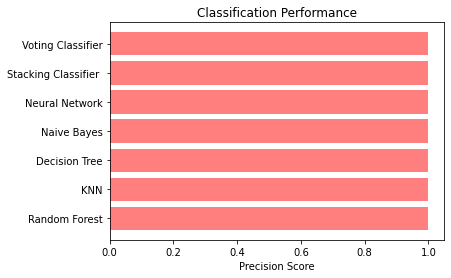

In [53]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, precision1, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

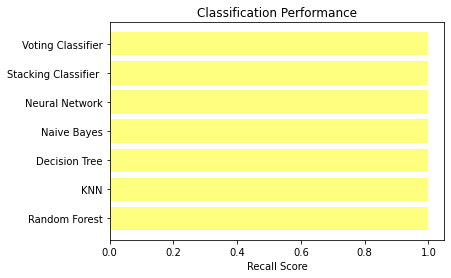

In [54]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, recall1, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

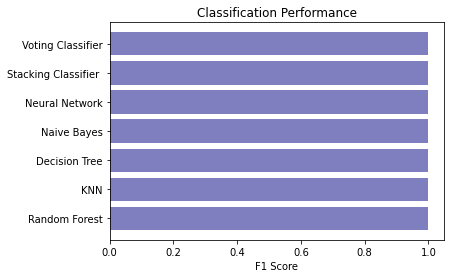

In [55]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, f1score1, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()